In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import sklearn
sklearn.set_config(display='text')

In [2]:
# 사이킷런이 제공하는 MNIST 손글씨 데이터를 불러오기 위해 import 한다.
from sklearn.datasets import load_digits
# kNN 알고리즘을 사용하기 위해 import 한다.
from sklearn.neighbors import KNeighborsClassifier
# SVM 알고리즘을 사용하기 위해 import 한다. SVC(Support Vector Classification)
from sklearn.svm import SVC
# 사이킷런의 의사결정 트리를 사용하기 위해 import 한다.
from sklearn.tree import DecisionTreeClassifier

사이킷런이 제공하는 MNIST 숫자 손글씨 데이터를 피쳐와 레이블로 불러와서 학습 데이터와 테스트 데이터로 나눈다.

In [3]:
dataset = load_digits()
# dataset.data: 피쳐, dataset.target: 레이블
x_train, x_test, y_train, y_test = train_test_split(dataset.data, dataset.target, train_size=0.8)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(1437, 64) (1437,) (360, 64) (360,)


단일 모델의 정확도를 측정한다.

앙상블 정확도를 측정하기에 앞서서 단일 모델들의 정확도를 kNN, SVM, 의사결정 트리 분류기를 만들어 정확도를 확인한다.

In [4]:
# kNN
model_kNN = KNeighborsClassifier(n_neighbors=299).fit(x_train, y_train) # 모델 생성 및 학습
predict = model_kNN.predict(x_test) # 예측
accuracy_kNN = accuracy_score(y_test, predict) # 정확도
print('kNN 정확도: {:6.2%}'.format(accuracy_kNN))

kNN 정확도: 86.39%


In [5]:
# SVM
# probability=True 속성은 SVM 모델이 VotingClassifier에 적용될 때 각 레이블의 확률값을 계산할 수 있도록 한다.
model_SVM = SVC(C=0.1, gamma=0.003, probability=True).fit(x_train, y_train) # 모델 생성 및 학습
predict = model_SVM.predict(x_test) # 예측
accuracy_SVM = accuracy_score(y_test, predict) # 정확도
print('SVM 정확도: {:6.2%}'.format(accuracy_SVM))

SVM 정확도: 92.50%


In [6]:
# 의사결정 트리
model_DT = DecisionTreeClassifier(max_depth=8).fit(x_train, y_train) # 모델 생성 및 학습
predict = model_DT.predict(x_test) # 예측
accuracy_DT = accuracy_score(y_test, predict) # 정확도
print('의사결정 트리 정확도: {:6.2%}'.format(accuracy_DT))

의사결정 트리 정확도: 85.56%


하드 보팅

일반적인 투표와 같이 각 분류기의 예측값들을 모아서 가장 많은 투표를 받은 예측값으로 최종 결론을 내린다.

In [7]:
# 하드, 소프트 보팅을 계산하기 위해 import 한다.
from sklearn.ensemble import VotingClassifier

In [8]:
model_HV = VotingClassifier(
    estimators=[('kNN', model_kNN), ('SVM', model_SVM), ('DT', model_DT)], # 앙상블 보팅 알고리즘에 적용할 개별 모델를 지정한다.
    weights=[1, 1, 1], # 가중치, [1, 1, 1]는 각 모델의 투표권을 동일하게 1장씩 배정한다.
    voting='hard'
).fit(x_train, y_train) # 모델 생성 및 학습
predict = model_HV.predict(x_test) # 예측
accuracy_HV = accuracy_score(y_test, predict) # 정확도
print('하드 보팅 앙상블 정확도: {:6.2%}'.format(accuracy_HV))

하드 보팅 앙상블 정확도: 94.72%


소프트 보팅

각 분류기별 확률을 더해준 값을 점수로 사용해서 최대 점수를 가진 예측값으로 최종 결론을 내린다.

In [9]:
# predict_proba() 메소드의 인수로 테스트 데이터의 피쳐값을 넘겨서 각 레이블이 선택될 확률을 계산한다.
proba_kNN = model_kNN.predict_proba(x_test)
# print(proba_kNN)
print(proba_kNN[0]) # 피쳐에 따른 레이블의 종류가 10개라서 10개가 선택될 확률을 출력한다.
print(proba_kNN[0].max())
print('확률 합계: {:6.2%}'.format(proba_kNN[0].sum()))

[0.44481605 0.01337793 0.00668896 0.00334448 0.15050167 0.01672241
 0.10702341 0.01337793 0.12374582 0.12040134]
0.44481605351170567
확률 합계: 100.00%


In [10]:
proba_SVM = model_SVM.predict_proba(x_test)
print(proba_SVM[0])
print(proba_SVM[0].max())
print('확률 합계: {:6.2%}'.format(proba_SVM[0].sum()))

[9.95483105e-01 4.65722248e-04 5.71845322e-04 3.38451269e-04
 4.59172758e-04 6.02208387e-04 5.16244509e-04 3.93782132e-04
 6.37192165e-04 5.32276070e-04]
0.9954831051391037
확률 합계: 100.00%


In [11]:
proba_DT = model_DT.predict_proba(x_test)
print(proba_DT[0])
print(proba_DT[0].max())
print('확률 합계: {:6.2%}'.format(proba_DT[0].sum()))

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1.0
확률 합계: 100.00%


In [12]:
model_SV = VotingClassifier(
    estimators=[('kNN', model_kNN), ('SVM', model_SVM), ('DT', model_DT)],
    weights=[1, 1, 1],
    voting='soft'
).fit(x_train, y_train)
predict = model_SV.predict(x_test)
accuracy_SV = accuracy_score(y_test, predict)
print('소프트 보팅 앙상블 정확도: {:6.2%}'.format(accuracy_SV))

소프트 보팅 앙상블 정확도: 93.06%


In [13]:
proba_SV = model_SV.predict_proba(x_test)
print(proba_SV[0])
print(proba_SV[0].max())
print('확률 합계: {:6.2%}'.format(proba_SV[0].sum()))

[0.81335925 0.00459845 0.00243957 0.00121617 0.05033462 0.0057908
 0.03585817 0.00456873 0.04149627 0.04033797]
0.8133592502002639
확률 합계: 100.00%


단일 모델(kNN, SVM, 의사결정 트리)과 보팅 앙상블(하드, 소프트) 모델들의 정확도 비교 시각화 

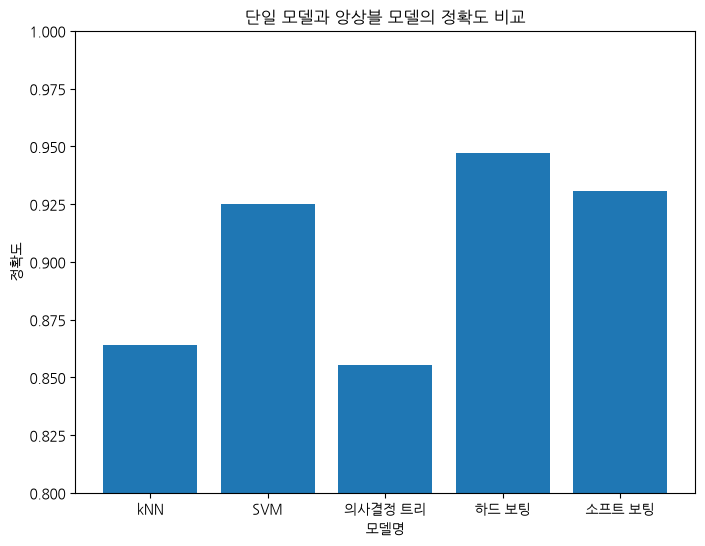

In [23]:
plt.figure(figsize=(8, 6))
plt.bar(
    np.arange(5),
    height=[accuracy_kNN, accuracy_SVM, accuracy_DT, accuracy_HV, accuracy_SV]
)
plt.title('단일 모델과 앙상블 모델의 정확도 비교')
plt.xlabel('모델명')
plt.ylabel('정확도')
plt.xticks(np.arange(5), ['kNN', 'SVM', '의사결정 트리', '하드 보팅', '소프트 보팅'])
plt.ylim(0.8, 1.0)
plt.show()